# Process-driven local bandwdith inference

In [1]:
from src.dataset.simulated_spatial_dataset import SimulatedSpatialDataset

## Prepare Dataset

Create y = beta1 * x1 + err, where x1 and err are randomly drawn from normal distribution

and beta1 is a composite GRF comes with different rate of change

In [2]:
k = 1
field_size = 60
dataset = SimulatedSpatialDataset(
    k=k,
    field_size=field_size,
    useIntercept=False
)
[X] = dataset.generate_data()
[beta] = dataset.generate_processes()
[y, err] = dataset.fit_y(X, beta)

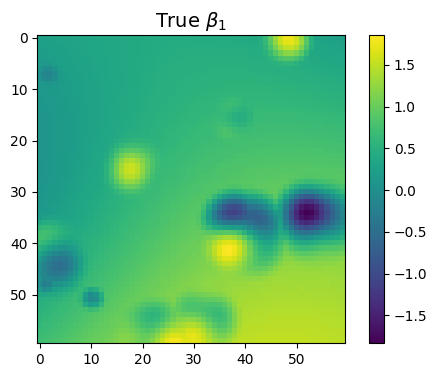

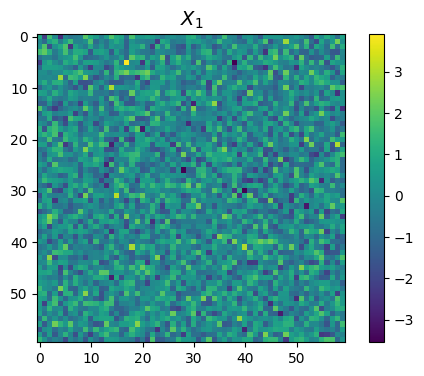

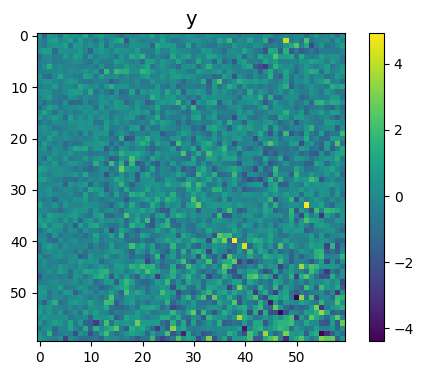

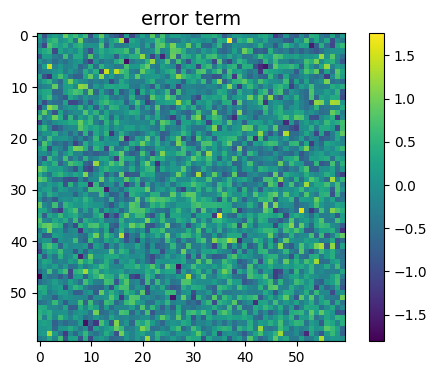

In [3]:
# Plot data in 2D graphs
dataset.plot(
    b=beta.T,
    sub_title=[r"True $\beta_1$"],
    size=field_size
)
dataset.plot(
    b=X.T,
    sub_title=[r"$X_1$"],
    size=field_size
)
dataset.plot(
    b=y.reshape(1, -1),
    sub_title=['y'],
    size=field_size
)
dataset.plot(
    b=err.reshape(1, -1),
    sub_title=['error term'],
    size=field_size
)

In [4]:
# Plot true process in 3D graph
fig = dataset.plot_process_3d(
    beta,
    title="True process (beta field)",
    show=True,
    # save_html="beta_surface.html"    
)

#### Stage 1: Global Bandwidth and Uncertainty Quantification

We begin by fitting a conventional GWR model using a single global bandwidth selected by minimizing the AICc criterion.
While a single optimal bandwidth is often treated as a point estimate of the spatial scale of the underlying process, recent work has shown that bandwidth selection is subject to non-negligible uncertainty.

Following Li et al. (2020), we compute a confidence interval (CI) for the bandwidth, which defines a range of smoothing scales that are statistically indistinguishable in terms of model fit.
This interval will later serve as the admissible domain for local bandwidth inference.

In [9]:
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR

g_X = dataset.X
g_y = dataset.y.reshape(-1, 1)
g_coords = dataset.coordinates.tolist()

# Select global bandwidth
selector = Sel_BW(g_coords, g_y, g_X, constant=False)
bw_opt = selector.search()

# Fit GWR at optimal bandwidth
gwr = GWR(g_coords, g_y, g_X, bw=bw_opt, constant=False)
gwr_res = gwr.fit()

# Bandwidth confidence interval (Li et al., 2020)
bw_ci = gwr_res.get_bws_intervals(selector, level=0.95)

print(f"The optimal global bandwidth : {bw_opt}")
print(f"The bandwidth confidence interval of this process : {bw_ci}")
fig = dataset.plot_process_3d(
    gwr_res.params[:, 0],
    title="Estimated process (beta field)",
    show=True
)


The optimal global bandwidth : 69.0
The bandwidth confidence interval of this process : (60.0, 69.0)


#### Stage 2: Finite-difference Hessian with reflective padding
To quantify second-order spatial variation in the estimated parameter surface,
we approximate the Hessian matrix of the GWR parameter estimate surface using second-order central finite differences.

Because central finite differences require a symmetric neighborhood,
boundary locations are handled via reflective padding.
This padding strategy extends the parameter surface beyond the observed domain
by mirroring interior values across the boundary, allowing the finite-difference
operator to be evaluated at all spatial locations without explicit extrapolation.

In [20]:
import numpy as np
import numpy.typing as npt

def compute_hessian_frobenius(
    beta: npt.ArrayLike,
    coords: npt.ArrayLike,
    step: int = 1,
):
    """
    Compute a local curvature proxy based on the Frobenius norm
    of the Hessian matrix of a spatial beta surface, using a
    finite-difference stencil with configurable step size.

    Parameters
    ----------
    beta : array-like, shape (n,)
        Estimated or true beta values at spatial locations.
    coords : array-like, shape (n, 2)
        Spatial coordinates corresponding to beta values.
        Assumed to lie on a regular grid.
    step : int, default=1
        Finite-difference step size (in grid cells).
        step=1 corresponds to the standard 3x3 stencil.
        Larger values probe curvature at coarser spatial scales.

    Returns
    -------
    H_frob : ndarray, shape (nx, ny)
        Frobenius norm of the Hessian at each grid cell.
    X : ndarray, shape (nx, ny)
        Grid of x-coordinates.
    Y : ndarray, shape (nx, ny)
        Grid of y-coordinates.
    """

    if step < 1 or not isinstance(step, int):
        raise ValueError("step must be a positive integer.")

    beta = np.asarray(beta).reshape(-1)
    coords = np.asarray(coords)

    if coords.shape[0] != beta.shape[0]:
        raise ValueError("beta and coords must have the same number of observations.")

    # -------------------------------------------------
    # Reshape beta onto regular grid
    # -------------------------------------------------
    x = coords[:, 0]
    y = coords[:, 1]

    xu = np.unique(x)
    yu = np.unique(y)

    nx, ny = len(xu), len(yu)

    x_to_i = {v: i for i, v in enumerate(np.sort(xu))}
    y_to_j = {v: j for j, v in enumerate(np.sort(yu))}

    B = np.full((nx, ny), np.nan)
    for (xi, yi), b in zip(coords, beta):
        B[x_to_i[xi], y_to_j[yi]] = b

    # Grid spacing
    dx = np.median(np.diff(np.sort(xu)))
    dy = np.median(np.diff(np.sort(yu)))

    # -------------------------------------------------
    # Reflective padding (width = step)
    # -------------------------------------------------
    B_pad = np.pad(B, pad_width=step, mode="reflect")

    # -------------------------------------------------
    # Finite-difference Hessian components (step-size aware)
    # -------------------------------------------------
    hdx = step * dx
    hdy = step * dy

    Bxx = (
        B_pad[2*step:, step:-step]
        - 2 * B_pad[step:-step, step:-step]
        + B_pad[:-2*step, step:-step]
    ) / (hdx ** 2)

    Byy = (
        B_pad[step:-step, 2*step:]
        - 2 * B_pad[step:-step, step:-step]
        + B_pad[step:-step, :-2*step]
    ) / (hdy ** 2)

    Bxy = (
        B_pad[2*step:, 2*step:]
        - B_pad[2*step:, :-2*step]
        - B_pad[:-2*step, 2*step:]
        + B_pad[:-2*step, :-2*step]
    ) / (4 * hdx * hdy)

    # -------------------------------------------------
    # Frobenius norm of Hessian
    # -------------------------------------------------
    H_frob = np.sqrt(Bxx**2 + Byy**2 + 2.0 * (Bxy**2))

    # -------------------------------------------------
    # Coordinate grids (for plotting)
    # -------------------------------------------------
    X, Y = np.meshgrid(np.sort(xu), np.sort(yu), indexing="ij")

    return H_frob, X, Y

# Estimated beta from GWR
H_hat, X, Y = compute_hessian_frobenius(
    beta=gwr_res.params[:, 0],
    coords=g_coords,
    step=10
)

# True beta (simulation)
H_true, _, _ = compute_hessian_frobenius(
    beta=beta.reshape(-1),
    coords=g_coords,
)


#### Hessian Frobenius norm and 3D visualization

To obtain a single, rotation-invariant measure of local second-order variation,
the Hessian matrix at each location is summarized using its Frobenius norm.

This scalar quantity provides a compact proxy for local curvature intensity
and facilitates spatial visualization and comparison across locations.

The resulting curvature surface is visualized as a 3D surface to assess
whether the inferred second-order structure reflects meaningful spatial patterns
rather than numerical artifacts.

In [21]:
import plotly.graph_objects as go


def plot_curvature_surface(
    H_frob,
    X,
    Y,
    title="Local curvature proxy (Hessian Frobenius norm)",
    colorscale="Viridis",
):
    """
    Plot a 3D surface of the Hessian Frobenius norm.

    Parameters
    ----------
    H_frob : ndarray (nx, ny)
        Curvature proxy surface.
    X, Y : ndarray (nx, ny)
        Coordinate grids.
    """

    fig = go.Figure(
        data=[
            go.Surface(
                x=X,
                y=Y,
                z=H_frob,
                colorscale=colorscale,
                showscale=True,
            )
        ]
    )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="x",
            yaxis_title="y",
            zaxis_title="||H||_F",
        ),
        margin=dict(l=0, r=0, b=0, t=40),
    )

    fig.show()


# Estimated beta from GWR
plot_curvature_surface(
    H_hat, X, Y,
    title="Curvature from estimated beta"
)

# True beta (simulation)
plot_curvature_surface(
    H_true, X, Y,
    title="Curvature from true beta"
)
